In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Ready")

✅ Ready


In [6]:
# Load data from txt file
df = pd.read_csv('../data/MachineLearningRating_v3.txt', delimiter='|', encoding='utf-8')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)[:5]}...")
df.head()

Shape: (1000098, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship']...


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.85,0.00
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00


In [7]:
# Calculate risk metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

# Portfolio metrics
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
claim_count = df['HasClaim'].sum()

print("=" * 50)
print("PORTFOLIO METRICS")
print("=" * 50)
print(f"Total Premium: R{total_premium:,.2f}")
print(f"Total Claims: R{total_claims:,.2f}")
print(f"Loss Ratio: {(total_claims/total_premium):.4f}")
print(f"Claim Rate: {(claim_count/len(df))*100:.4f}%")
print(f"Avg Claim Severity: R{df[df['HasClaim']==1]['TotalClaims'].mean():,.2f}")

PORTFOLIO METRICS
Total Premium: R61,911,562.70
Total Claims: R64,867,546.17
Loss Ratio: 1.0477
Claim Rate: 0.2788%
Avg Claim Severity: R23,273.39


MISSING VALUES
                         Missing %
NumberOfVehiclesInFleet     100.00
CrossBorder                  99.93
CustomValueEstimate          77.96
Rebuilt                      64.18
WrittenOff                   64.18
Converted                    64.18
LossRatio                    38.14
NewVehicle                   15.33
Bank                         14.59
AccountType                   4.02
Gender                        0.95
MaritalStatus                 0.83
make                          0.06
mmcode                        0.06
VehicleType                   0.06
VehicleIntroDate              0.06
NumberOfDoors                 0.06
bodytype                      0.06
kilowatts                     0.06
Cylinders                     0.06
cubiccapacity                 0.06
Model                         0.06
CapitalOutstanding            0.00


<Figure size 1000x500 with 0 Axes>

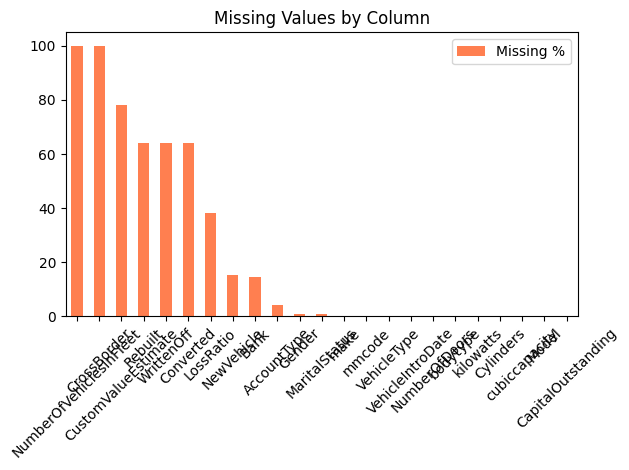

In [8]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %', ascending=False)

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(missing_df)

# Plot
if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    missing_df.plot(kind='bar', color='coral')
    plt.title('Missing Values by Column')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

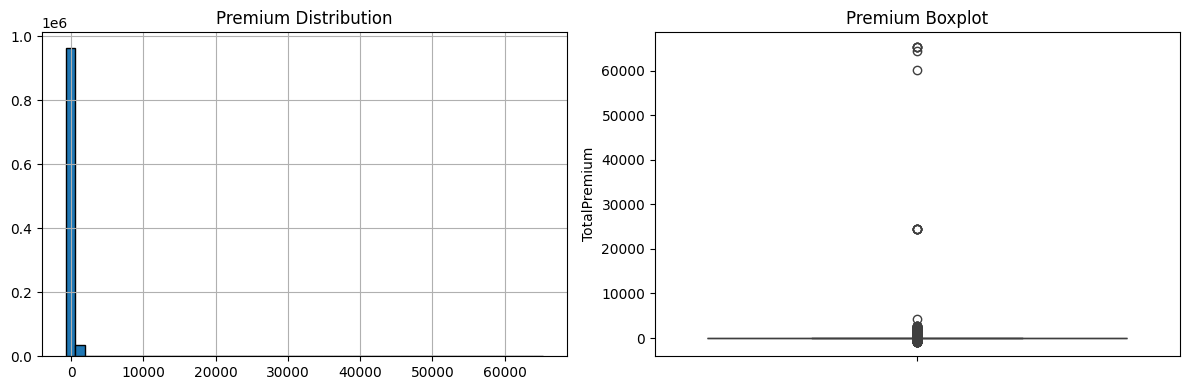

In [9]:
# Visualization 1: Premium Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df['TotalPremium'].hist(bins=50, ax=ax1, edgecolor='black')
ax1.set_title('Premium Distribution')
sns.boxplot(y=df['TotalPremium'], ax=ax2)
ax2.set_title('Premium Boxplot')
plt.tight_layout()
plt.show()

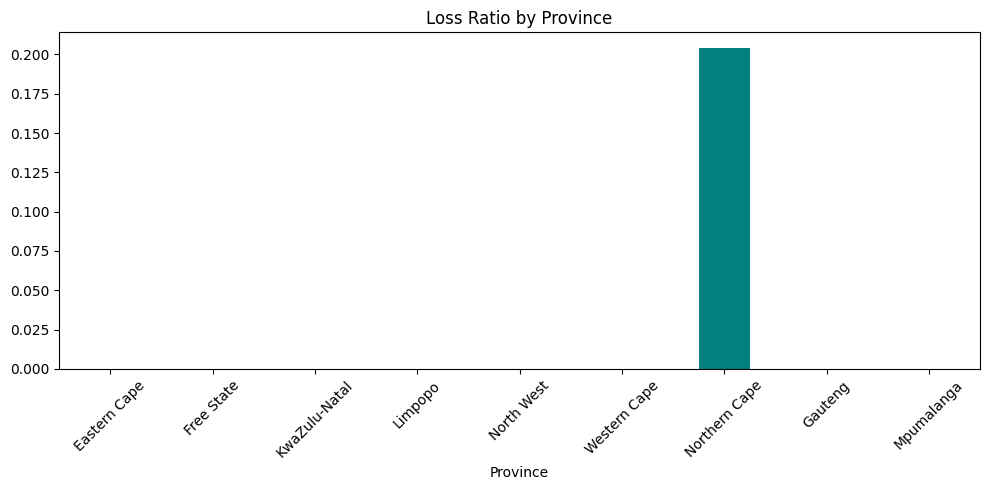

In [10]:
# Visualization 2: Loss Ratio by Province
if 'Province' in df.columns:
    loss_by_province = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 5))
    loss_by_province.plot(kind='bar', color='teal')
    plt.title('Loss Ratio by Province')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Province column not found - available columns:", list(df.columns)[:10])

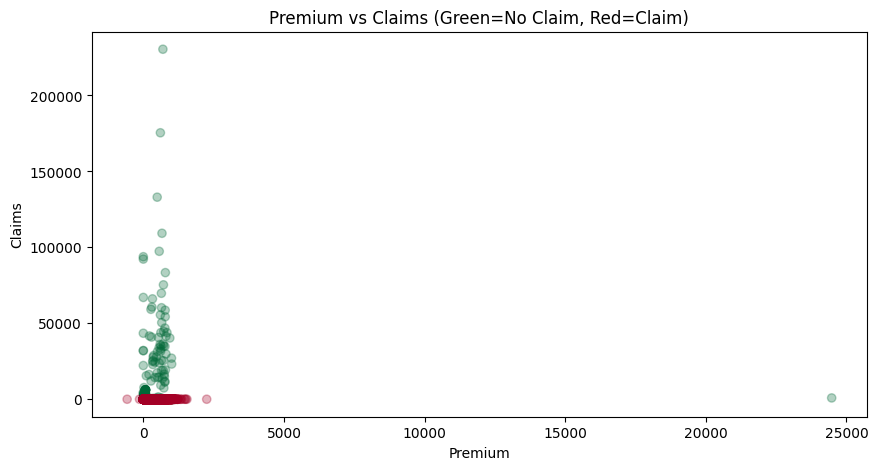

In [11]:
# Visualization 3: Premium vs Claims
sample = df.sample(min(50000, len(df)))
plt.figure(figsize=(10, 5))
plt.scatter(sample['TotalPremium'], sample['TotalClaims'], alpha=0.3, c=sample['HasClaim'], cmap='RdYlGn')
plt.xlabel('Premium')
plt.ylabel('Claims')
plt.title('Premium vs Claims (Green=No Claim, Red=Claim)')
plt.show()

RISK SEGMENTATION
Low Risk: 615,821 (61.6%)
Medium Risk: 381,505 (38.1%)
High Risk: 2,772 (0.3%)


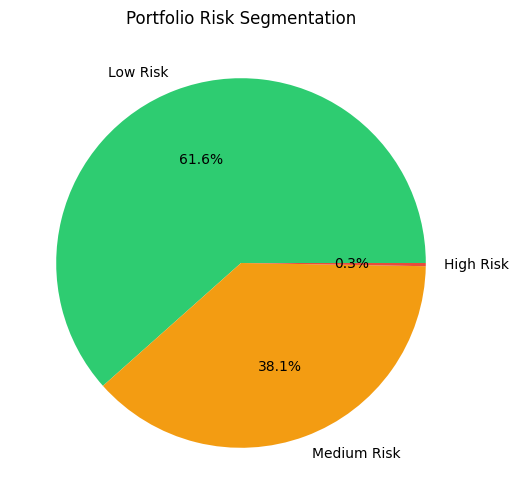


✅ Task 1 Complete! Saved processed_data.csv


In [12]:
# Risk Segmentation
def risk_category(row):
    if row['LossRatio'] == 0:
        return 'Low Risk'
    elif row['LossRatio'] > 1:
        return 'High Risk'
    return 'Medium Risk'

df['RiskCategory'] = df.apply(risk_category, axis=1)
risk_counts = df['RiskCategory'].value_counts()
risk_pct = (risk_counts / len(df)) * 100

print("=" * 50)
print("RISK SEGMENTATION")
print("=" * 50)
for cat in ['Low Risk', 'Medium Risk', 'High Risk']:
    if cat in risk_counts.index:
        print(f"{cat}: {risk_counts[cat]:,} ({risk_pct[cat]:.1f}%)")

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Portfolio Risk Segmentation')
plt.show()

# Save for DVC
df.to_csv('../data/processed_data.csv', index=False)
print("\n✅ Task 1 Complete! Saved processed_data.csv")